
# Importing Libraries

In [2]:
# to handle tabular data
import pandas as pd
import numpy as np
# cross validation
from sklearn.model_selection import train_test_split
# Algorithms
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
# Normalizing
from sklearn.preprocessing import StandardScaler
# Evaluation
from sklearn.metrics import accuracy_score,classification_report,f1_score, confusion_matrix
import warnings
warnings.simplefilter("ignore")

In [3]:
# visualize the data
import matplotlib.pyplot as plt
import seaborn as sns


# About Dataset

This dataset focuses on air quality assessment across various regions. The dataset contains 5000 samples and captures critical environmental and demographic factors that influence pollution levels.

Key Features:

Temperature (°C): Average temperature of the region.

Humidity (%): Relative humidity recorded in the region.

PM2.5 Concentration (µg/m³): Fine particulate matter levels.

PM10 Concentration (µg/m³): Coarse particulate matter levels.

NO2 Concentration (ppb): Nitrogen dioxide levels.

SO2 Concentration (ppb): Sulfur dioxide levels.

CO Concentration (ppm): Carbon monoxide levels.

Proximity to Industrial Areas (km): Distance to the nearest industrial zone.

Population Density (people/km²): Number of people per square kilometer in the region.

Target Variable: Air Quality Levels

Good: Clean air with low pollution levels.

Moderate: Acceptable air quality but with some pollutants present.

Poor: Noticeable pollution that may cause health issues for sensitive groups.

Hazardous: Highly polluted air posing serious health risks to the population.

# Reading of the data

In [4]:
data=pd.read_csv('updated_pollution_dataset.csv')

In [5]:
data

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good
...,...,...,...,...,...,...,...,...,...,...
4995,40.6,74.1,116.0,126.7,45.5,25.7,2.11,2.8,765,Hazardous
4996,28.1,96.9,6.9,25.0,25.3,10.8,1.54,5.7,709,Moderate
4997,25.9,78.2,14.2,22.1,34.8,7.8,1.63,9.6,379,Moderate
4998,25.3,44.4,21.4,29.0,23.7,5.7,0.89,11.6,241,Good


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB


# Statistical Analysis of the data
 

In [7]:
data.describe()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.029020,70.056120,20.142140,30.218360,26.412100,10.014820,1.500354,8.425400,497.423800
std,6.720661,15.863577,24.554546,27.349199,8.895356,6.750303,0.546027,3.610944,152.754084
min,13.400000,36.000000,0.000000,-0.200000,7.400000,-6.200000,0.650000,2.500000,188.000000
25%,25.100000,58.300000,4.600000,12.300000,20.100000,5.100000,1.030000,5.400000,381.000000
50%,29.000000,69.800000,12.000000,21.700000,25.300000,8.000000,1.410000,7.900000,494.000000
75%,34.000000,80.300000,26.100000,38.100000,31.900000,13.725000,1.840000,11.100000,600.000000
max,58.600000,128.100000,295.000000,315.800000,64.900000,44.900000,3.720000,25.800000,957.000000


# Finding the presence of the null values in the dataset

In [8]:
data.isna().sum()/len(data)*100

Temperature                      0.0
Humidity                         0.0
PM2.5                            0.0
PM10                             0.0
NO2                              0.0
SO2                              0.0
CO                               0.0
Proximity_to_Industrial_Areas    0.0
Population_Density               0.0
Air Quality                      0.0
dtype: float64

# Finding the presence of duplicated values in the dataset


In [9]:
data[data.duplicated()].shape

(0, 10)

# Performing the Data Analysis on each column of the dataset individually


Analysis of the Target Variable Air Quality


<Axes: xlabel='Air Quality', ylabel='count'>

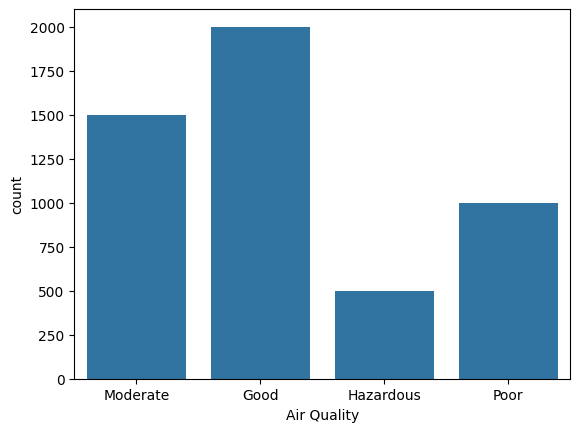

In [10]:
sns.countplot(data=data,x='Air Quality')

Analysis of the each columns individually based on the data given

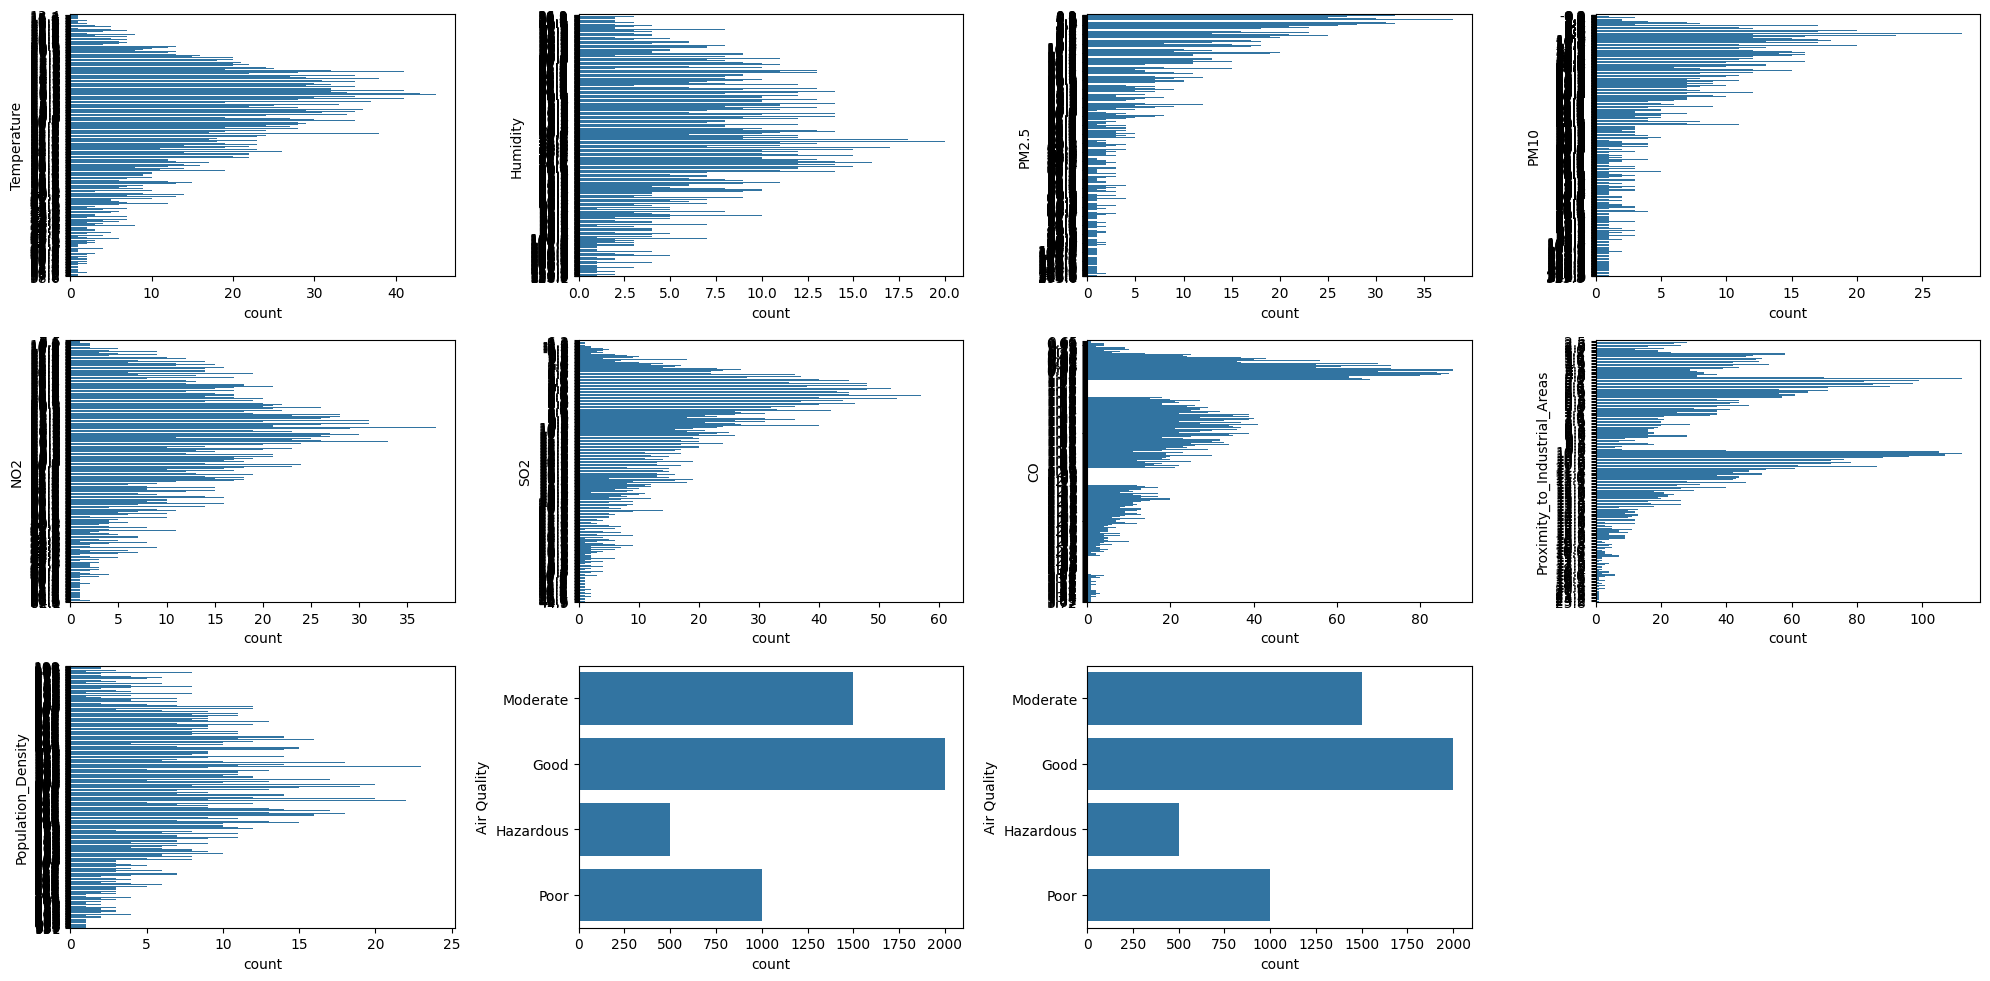

In [11]:
plt.figure(figsize=(20,16))
c = 1
for i in data.columns:
        plt.subplot(5,4,c)
        sns.countplot(data=data,y=i)
        c += 1
        if data[i].dtype == np.dtype("object"):
            plt.subplot(5,4,c)
            sns.countplot(data=data,y=i)
plt.tight_layout()
plt.show()

# Observations:

Temperature:

The data is slightly skewed to the right, with most values concentrated between 20°C and 30°C.
There are a few extreme values above 50°C, which may require further investigation for outliers.

Humidity:

The distribution appears left-skewed, with most values clustered between 60% and 100%.
There is a small range of lower humidity values (~40%-60%).

PM2.5 and PM10:

Both features exhibit strong right-skewed distributions, with the majority of values concentrated at lower levels.
A few extremely high values might indicate outliers, particularly for PM2.5 and PM10 exceeding 100 units.

NO2:

The data is moderately right-skewed, with most values concentrated below 30 units.
There are relatively fewer occurrences of high NO2 values above 50 units.

SO2:

The data shows a right-skewed distribution, with most values below 10 units.
There are some higher SO2 values, but they are less frequent.

CO:

The CO levels have a right-skewed distribution, with most values between 0.5 and 1.5 units.
A small number of samples have higher CO concentrations above 2.5 units.

Proximity to Industrial Areas:

This feature has a bimodal distribution, indicating two distinct groups: one closer to industrial areas (values below 10) and another farther away (values near 15-20).
This could reflect distinct geographical zones.

Population Density:

The data appears normally distributed, with most values centered around 400-600 units.
Extremely low or high population densities are less frequent.

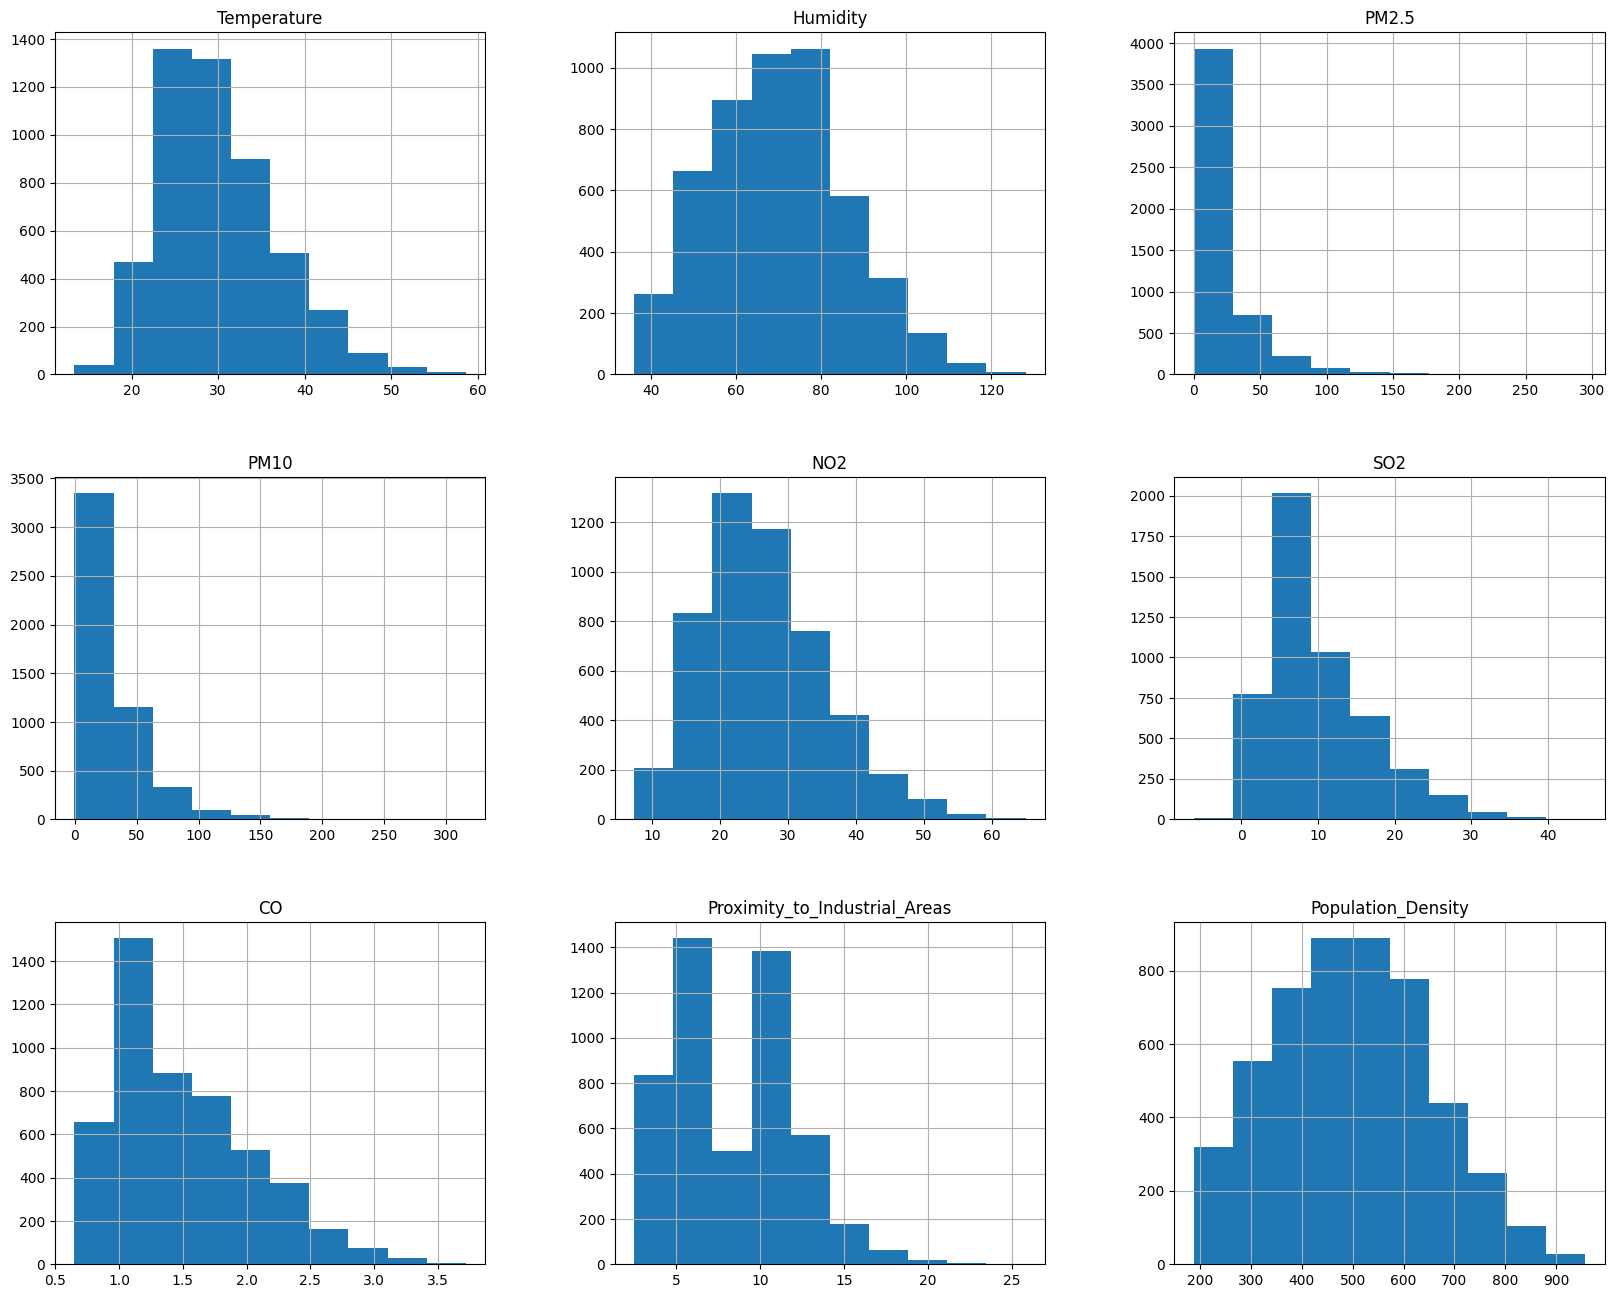

In [12]:
plt=data.hist(figsize=(20,16))


# Finding the number of unique parameters in object type data


In [13]:
data['Air Quality'].unique()

array(['Moderate', 'Good', 'Hazardous', 'Poor'], dtype=object)

# Encoding of the Object Type data  into numericl data


In [14]:
data['Air Quality'].replace(['Moderate', 'Good', 'Hazardous', 'Poor'],[0,1,2,3],inplace=True)

# Finding the co-relation among all the parameters by using a co-relation heat map

Strong correlation: Absolute value > 0.7.

Moderate correlation: Absolute value between 0.4 and 0.7.

Weak correlation: Absolute value < 0.4.

Negative sign (-): As one variable increases, the other variable tends to decrease. For example, as temperature increases, the demand for heating may decrease.

In [16]:
plt.figure(figsize = (20,17))
sns.heatmap(data.corr(),square=True,annot=True)
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'figure'

# Key Observations from the HeatMap:

Strong Correlations with Air Quality:

Features like CO and Population Density show moderate positive correlations with Air Quality. This suggests that higher levels of CO and densely populated areas might be associated with changes in air quality.
Proximity to Industrial Areas has a slight negative correlation with Air Quality, implying that proximity to industrial zones might degrade air quality.

Inter-feature Relationships:

There is a very high correlation between PM2.5 and PM10 (~0.97), which indicates potential multicollinearity. These features might carry redundant information.
CO exhibits strong positive correlations with SO2 (~0.68) and NO2 (~0.71), suggesting that these pollutants might be co-emitted or influenced by similar sources.
Negative Correlations:

Proximity to Industrial Areas shows strong negative correlations with several pollutants, such as NO2 (-0.61) and CO (-0.71), as well as Temperature (~-0.59). This aligns with industrial areas being significant pollution sources.
Weak Correlations:

Features such as Humidity and Temperature show weaker correlations with Air Quality, suggesting a more indirect influence on the target variable.

# Dividing the data into input and output values


In [23]:
x=data.drop(columns=['Air Quality'])
y=pd.DataFrame(data['Air Quality'])

# Scaling on the input data to achieve higher accuracy after the training

In [24]:
scalerx = StandardScaler()
scaled_x = scalerx.fit_transform(x)
print(scaled_x.shape)
print(y)

(5000, 9)
      Air Quality
0               0
1               0
2               0
3               1
4               1
...           ...
4995            2
4996            0
4997            0
4998            1
4999            0

[5000 rows x 1 columns]


Performing the Test Train Split to divide the data for training and testing and using various classifiers to train the data.

In [25]:
X_train,X_test,y_train,y_test = train_test_split(scaled_x,y,test_size=0.2,random_state=0)

# Decision Tree Classifier

In [27]:
# instantiating the Algorithm
dtc = DecisionTreeClassifier(class_weight="balanced",random_state=6)

# Training the model
dtc.fit(X_train,y_train)

# Testing the model
y_pred = dtc.predict(X_test)  

In [28]:
print("Accuracy Score: ",accuracy_score(y_test,y_pred)*100,"%")
a=accuracy_score(y_test,y_pred)*100
print('F1 score for each class:', f1_score(y_test, y_pred, average=None))


Accuracy Score:  91.8 %
F1 score for each class: [0.94594595 0.99390987 0.75829384 0.79787234]


In [29]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95       295
           1       1.00      0.99      0.99       411
           2       0.76      0.75      0.76       106
           3       0.80      0.80      0.80       188

    accuracy                           0.92      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.92      0.92      0.92      1000



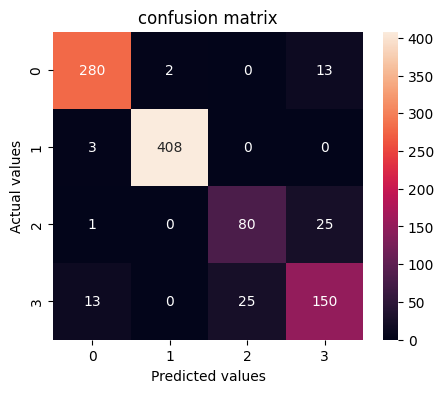

In [30]:
plt.figure(figsize=(5,4))
plt.title("confusion matrix")
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="d")
plt.xlabel("Predicted values")
plt.ylabel("Actual values")
plt.show()

# Analysis:

Class 0 (Top-left corner):

True Positives (TP): 280 samples were correctly predicted as class 0.

False Negatives (FN): 13 samples from class 0 were misclassified as class 3.

False Positives (FP): 2 samples were incorrectly classified as class 0 but actually belong to class 1.

Class 1:

True Positives (TP): 408 samples were correctly predicted as class 1.

False Negatives (FN): 3 samples were misclassified as class 0.

False Positives (FP): No misclassifications from other classes to class 1.

Class 2:

True Positives (TP): 80 samples were correctly classified as class 2.

False Negatives (FN): 25 samples were misclassified as class 3.

False Positives (FP): 1 sample was incorrectly classified as class 2 but actually belongs to class 0.

Class 3:

True Positives (TP): 150 samples were correctly classified as class 3.

False Negatives (FN): 25 samples were misclassified as class 2, and 13 samples as class 0.

False Positives (FP): 25 samples were incorrectly classified as class 3 but actually belong to class 2.

Key Observations:

High Performance for Class 1: Class 1 has the highest true positives (408) and the lowest misclassifications, indicating that the model performs exceptionally well for this class.

Confusion Between Class 2 and Class 3:

There is notable misclassification between class 2 and class 3 (25 samples in both directions), suggesting overlapping features or insufficient separation between these classes.

Class 0 and Class 3 Misclassifications:

13 samples from class 0 are misclassified as class 3, which may suggest some similarity in their feature space.

# Random Forest Classifier

In [17]:
# instantiating the Algorithm
rfc = RandomForestClassifier(class_weight="balanced_subsample",random_state=6)

# Training the model
rfc.fit(X_train,y_train)

# Testing the model
y_pred = rfc.predict(X_test) 

NameError: name 'X_train' is not defined

In [32]:
print("Accuracy Score: ",accuracy_score(y_test,y_pred)*100,"%")
b=accuracy_score(y_test,y_pred)*100
print('F1 score for each class:', f1_score(y_test, y_pred, average=None))


Accuracy Score:  94.6 %
F1 score for each class: [0.9678511  1.         0.82758621 0.859375  ]


In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       295
           1       1.00      1.00      1.00       411
           2       0.87      0.79      0.83       106
           3       0.84      0.88      0.86       188

    accuracy                           0.95      1000
   macro avg       0.92      0.91      0.91      1000
weighted avg       0.95      0.95      0.95      1000



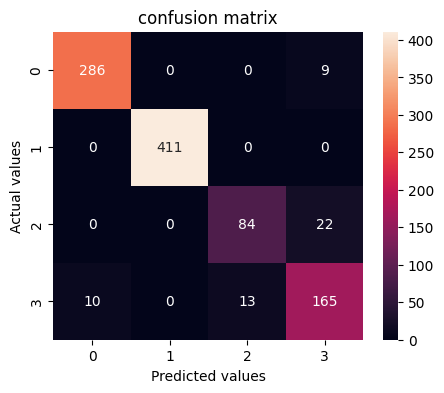

In [34]:
plt.figure(figsize=(5,4))
plt.title("confusion matrix")
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="d")
plt.xlabel("Predicted values")
plt.ylabel("Actual values")
plt.show()

# Analysis

Class 0:

True Positives: 286 instances were correctly classified as 0.

False Negatives: 9 instances of 0 were misclassified as other classes.

The model performs very well for this class, as most predictions are accurate.

Class 1:

True Positives: 411 instances were correctly classified as 1.

False Negatives: None were misclassified into other classes.

False Positives: There are no misclassifications from other classes into 1.

Excellent performance for class 1.

Class 2:

True Positives: 84 instances were correctly classified as 2.

False Negatives: 22 instances of 2 were classified as other classes.

The model struggles more with classifying this class accurately compared to 0 and 1.

Class 3:

True Positives: 165 instances were correctly classified as 3.

False Negatives: 23 instances (10 misclassified as 0 and 13 as 2).

While most predictions are accurate, there is room for improvement in distinguishing 3.

Key Insights:

The model performs best on classes 0 and 1, achieving near-perfect classification.

For classes 2 and 3, there is significant misclassification, particularly between neighboring classes (2 and 3).

Improving class separation and handling imbalances in training data may reduce misclassification.

# SVM Classifier

In [35]:
# instantiating the Algorithm
svm = SVC(max_iter=5000,C=7,gamma=.1)

# Training the model
svm.fit(X_train,y_train)

# Testing the model
svm_pred = svm.predict(X_test)

In [36]:
print("Accuracy Score: ",accuracy_score(y_test,svm_pred)*100,"%")
c=accuracy_score(y_test,svm_pred)*100
print('F1 score for each class:', f1_score(y_test, y_pred, average=None))

Accuracy Score:  94.19999999999999 %
F1 score for each class: [0.9678511  1.         0.82758621 0.859375  ]


In [37]:
print(classification_report(y_test,svm_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       295
           1       1.00      1.00      1.00       411
           2       0.84      0.79      0.82       106
           3       0.84      0.85      0.85       188

    accuracy                           0.94      1000
   macro avg       0.91      0.90      0.91      1000
weighted avg       0.94      0.94      0.94      1000



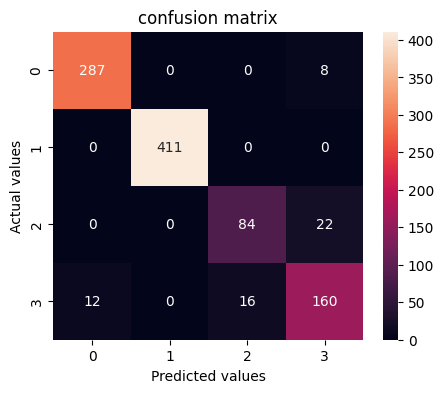

In [38]:
plt.figure(figsize=(5,4))
plt.title("confusion matrix")
sns.heatmap(confusion_matrix(y_test,svm_pred),annot=True,fmt="d")
plt.xlabel("Predicted values")
plt.ylabel("Actual values")
plt.show()

# Observations:

Class 0 (Row 0):

True Positives: 287 instances correctly classified as class 0.

False Negatives: 8 instances misclassified as other classes.

Performance for this class is excellent, with a very high correct classification rate.

Class 1 (Row 1):

True Positives: 411 instances correctly classified as class 1.

False Negatives: No instances misclassified.

This class achieves perfect classification performance.

Class 2 (Row 2):

True Positives: 84 instances correctly classified as class 2.

False Negatives: 22 instances misclassified into other classes.

Class 2 shows relatively lower performance compared to classes 0 and 1, with a significant number of misclassifications.

Class 3 (Row 3):

True Positives: 160 instances correctly classified as class 3.

False Negatives: 28 instances misclassified into other classes (12 to class 0 and 16 to class 2).

Class 3 shows a moderate level of performance with some notable misclassifications.

General Insights:

High Accuracy for Classes 0 and 1: These classes show strong classification accuracy, with very few misclassifications.

Lower Accuracy for Classes 2 and 3: These classes exhibit higher misclassification rates, possibly indicating the need for 
improvement in the model's ability to distinguish these classes.

Class Imbalance or Complexity: The model might struggle with specific class features or have data imbalance issues affecting classes 2 and 3.

# K Neighbours Classifier

In [39]:
knc = KNeighborsClassifier(n_neighbors=10,n_jobs=4)

# Training the model
knc.fit(X_train,y_train)

# Testing the model
y_pred = rfc.predict(X_test) 

In [40]:
print("Accuracy Score: ",accuracy_score(y_test,y_pred)*100,"%")
d=accuracy_score(y_test,y_pred)*100
print('F1 score for each class:', f1_score(y_test, y_pred, average=None))

Accuracy Score:  94.6 %
F1 score for each class: [0.9678511  1.         0.82758621 0.859375  ]


In [41]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       295
           1       1.00      1.00      1.00       411
           2       0.87      0.79      0.83       106
           3       0.84      0.88      0.86       188

    accuracy                           0.95      1000
   macro avg       0.92      0.91      0.91      1000
weighted avg       0.95      0.95      0.95      1000



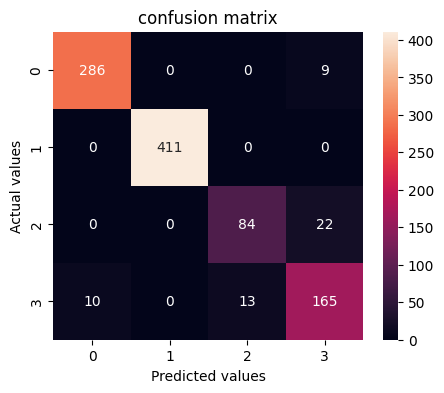

In [42]:
plt.figure(figsize=(5,4))
plt.title("confusion matrix")
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="d")
plt.xlabel("Predicted values")
plt.ylabel("Actual values")
plt.show()

# Confusion Matrix Details:

Class 0:

Correct Predictions: 286 instances were correctly classified as 0.

Misclassifications: 9 instances of class 0 were misclassified as class 3.

Precision and Recall for Class 0: Likely high due to a significant number of correct predictions.

Class 1:

Correct Predictions: 411 instances were correctly classified as 1.

Misclassifications: None, indicating perfect classification for this class.

Precision and Recall for Class 1: Both would be 100% as there are no false positives or false negatives.

Class 2:

Correct Predictions: 84 instances were correctly classified as 2.

Misclassifications:

22 instances of class 2 were misclassified as class 3.

Error Rate: A relatively moderate error rate in identifying class 2 compared to class 3.

Class 3:

Correct Predictions: 165 instances were correctly classified as 3.

Misclassifications:

10 instances of class 3 were misclassified as class 0.

13 instances were misclassified as class 2.

Challenge: The model struggles with distinguishing between class 3 and other classes.

Overall Observations:

Dominant Class (High Performance): Class 1 has the best classification performance with no errors.

Confusion Between Classes: There is significant confusion between classes 2 and 3, as well as between classes 0 and 3.

Model Strength: The model performs well for dominant and clearly distinguishable classes.

# Logistic Regression

In [43]:
# instantiating the Algorithm
lr = LogisticRegression()

# Training the model
lr.fit(X_train,y_train)

# Testing the model
y_pred = lr.predict(X_test)  

Accuracy Score:  93.89999999999999 %
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       295
           1       1.00      1.00      1.00       411
           2       0.86      0.79      0.82       106
           3       0.83      0.86      0.85       188

    accuracy                           0.94      1000
   macro avg       0.91      0.90      0.91      1000
weighted avg       0.94      0.94      0.94      1000



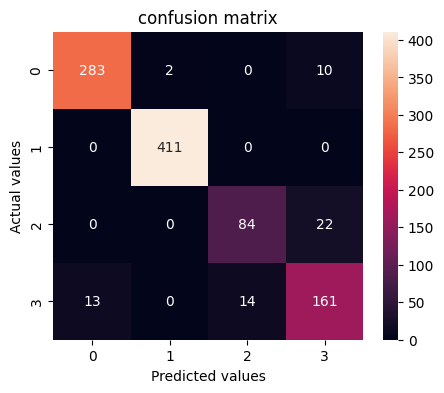

In [44]:
print("Accuracy Score: ",accuracy_score(y_test,y_pred)*100,"%")
e=accuracy_score(y_test,y_pred)*100
print(classification_report(y_test,y_pred))
plt.figure(figsize=(5,4))
plt.title("confusion matrix")
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="d")
plt.xlabel("Predicted values")
plt.ylabel("Actual values")
plt.show()

# Observations:

Class 0:

True Positives (correct predictions): 283.

False Negatives (misclassified as other classes): 12 (10 as class 3, 2 as class 1).

The model performs well for class 0, with a few misclassifications.

Class 1:

True Positives: 411.

False Negatives: None (no misclassifications as other classes).

Perfect prediction for class 1.

Class 2:

True Positives: 84.

False Negatives: 22 (misclassified as class 3).

The model struggles more with class 2, with a significant portion misclassified as class 3.

Class 3:

True Positives: 161.

False Negatives: 27 (13 as class 0, 14 as class 2).

The model has moderate performance for class 3.

Key Metrics:

Accuracy: The proportion of correct predictions out of all predictions.
 
Precision and Recall (for each class):

Precision: Fraction of correct predictions for a given class.

Recall: Fraction of actual instances of a class correctly predicted.

Analysis:

The model performs very well for class 1, with perfect predictions.

Class 0 also has high accuracy but a small number of misclassifications.

The model struggles with differentiating between class 2 and class 3, suggesting overlapping features or inadequate training data for these classes.

Improvement is needed in handling class 3, as a noticeable number of its instances are misclassified.

[91.8, 94.6, 94.19999999999999, 94.6, 93.89999999999999]


Text(0, 0.5, 'Accuracy')

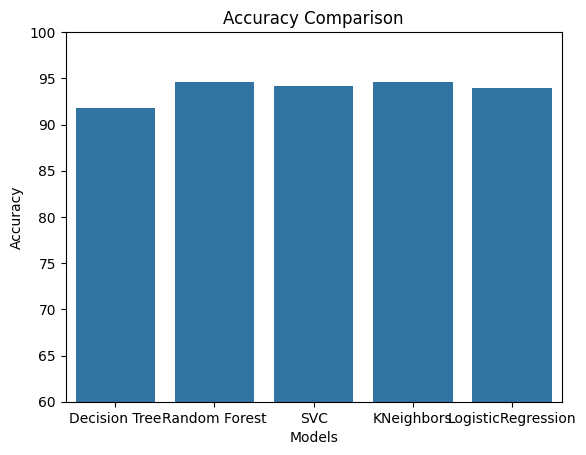

In [45]:
algorithms = ['Decision Tree','Random Forest','SVC','KNeighbors','LogisticRegression']
Accuracy=[a,b,c,d,e]
print(Accuracy)
accplot = sns.barplot(x=algorithms, y=Accuracy)
accplot.set_ylim(60, 100)
accplot.set_title("Accuracy Comparison")
accplot.set_xlabel("Models")
accplot.set_ylabel("Accuracy")

# Observations:

Decision Tree:

Accuracy is the lowest among all models.

Indicates potential overfitting or lack of generalization compared to other methods.

Random Forest:

Has the highest accuracy among all models.

Likely benefits from ensemble learning, reducing overfitting and improving performance.

SVC:

Accuracy is slightly lower than Random Forest but still very high.

Suggests that the data is well-suited for a linear or kernel-based decision boundary.

K-Nearest Neighbors:

Accuracy is very similar to Random Forest and SVC.

Indicates that the data may have well-separated classes that KNeighbors can classify effectively.

Logistic Regression:

Accuracy is comparable to SVC and KNeighbors, indicating good linear separability in the dataset.

Key Takeaways:

Random Forest Model is the best-performing model in terms of accuracy.

Decision Tree Model underperforms compared to others, suggesting that single-tree models may not capture the complexity of the data as effectively as ensemble or other sophisticated methods.

The small differences in accuracy among Random Forest, SVC, KNeighbors, and Logistic Regression suggest the data is well-suited for classification, and multiple algorithms perform well.

# Using Pickle Module to load and save the model

In [46]:
import pickle

with open("rf.pkl",'wb') as f:
    pickle.dump(rfc,f)

with open("x_scaler.pkl",'wb') as f:
    pickle.dump(scalerx,f)


In [47]:
with open("rf.pkl",'rb') as f:
    rf = pickle.load(f)

with open("x_scaler.pkl",'rb') as f:
    inscaler = pickle.load(f)

In [48]:
input=[[9,39,6,9,13,5,1,11,510]]
scaledinput = inscaler.transform(input)
rf_pred = rf.predict(scaledinput)
rf_pred

array([1], dtype=int64)

In [49]:
def Weather_Update(input):
    clf=pickle.load(open('rf.pkl','rb'))
    i_scaler = pickle.load(open("x_scaler.pkl","rb"))
    scaled_input = i_scaler.transform([input])
    pred=clf.predict(scaled_input)
    return pred[0]




In [50]:
Weather_Update([28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611])

0